# K-Nearest Neighbors (KNN)

<center>
  <img src="https://miro.medium.com/max/1151/0*ItVKiyx2F3ZU8zV5"><br>
  image from: <a href="https://ai.plainenglish.io/introduction-to-k-nearest-neighbors-knn-algorithm-e8617a448fa8">Introduction to k-Nearest Neighbors (kNN) Algorithm | by Rajvi Shah |  Artificial Intelligence in Plain English</a>
</center>

# Lab-1 Wine quality classification (Binary classification)
- ใช้ dataset จากไฟล์ `winequality.csv`
  1. **Fixed Acidity (ความเป็นกรดคงที่):** ปริมาณกรดในไวน์ที่ไม่ระเหยได้ง่าย มีความสำคัญในการให้รสชาติเปรี้ยว
  2. **Volatile Acidity (ความเป็นกรดระเหย):** ปริมาณกรดที่ระเหยได้ง่ายเช่น กรดแอซิติก ถ้ามีปริมาณมากเกินไปจะทำให้ไวน์มีกลิ่นเหมือนน้ำส้มสายชู
  3. **Citric Acid (กรดซิตริก):** กรดที่พบในผลไม้ ให้รสชาติเปรี้ยวสดชื่นและช่วยเพิ่มความสดของไวน์
  4. **Residual Sugar (น้ำตาลที่เหลืออยู่):** ปริมาณน้ำตาลที่ยังเหลืออยู่หลังจากการหมัก ไวน์ที่มีน้ำตาลเหลือมากจะมีรสหวาน
  5. **Chlorides (คลอไรด์):** ปริมาณเกลือในไวน์ ถ้ามีปริมาณมากเกินไปจะทำให้ไวน์มีรสเค็ม
  6. **Free Sulfur Dioxide (ซัลเฟอร์ไดออกไซด์อิสระ):** ปริมาณซัลเฟอร์ไดออกไซด์ในไวน์ที่ไม่ได้ทำปฏิกิริยากับสารอื่นๆ ช่วยป้องกันไวน์จากการออกซิเดชันและการเสียหายจากเชื้อรา
  7. **Total Sulfur Dioxide (ซัลเฟอร์ไดออกไซด์ทั้งหมด):** ปริมาณรวมของซัลเฟอร์ไดออกไซด์ทั้งที่อิสระและที่ทำปฏิกิริยากับสารอื่นๆในไวน์
  8. **Density (ความหนาแน่น):** ความหนาแน่นของไวน์ ซึ่งมีความสัมพันธ์กับปริมาณน้ำตาลและแอลกอฮอล์ในไวน์
  9. **pH (ค่าความเป็นกรด-ด่าง):** ค่าที่แสดงความเป็นกรดหรือเบสของไวน์ ไวน์ทั่วไปจะมีค่า pH อยู่ระหว่าง 3 ถึง 4
  10. **Sulphates (ซัลเฟต):** สารประกอบที่ช่วยเพิ่มกลิ่นหอมของไวน์และป้องกันการเกิดออกซิเดชัน
  11. **Alcohol (แอลกอฮอล์):** ปริมาณแอลกอฮอล์ในไวน์ มีผลต่อรสชาติและความรู้สึกเมา
  12. **Quality (คุณภาพ):** คุณภาพของไวน์ 0 - Bad Wine, 1 - Good Wine

## Preparation

* เชื่อมต่อ google drive
* upload ไฟล์ data/winequality-red (binary).csv

* สร้าง DataFrame จากไฟล์ data/winequality-red (binary).csv

In [2]:
import pandas as pd
wine_df = pd.read_csv('data/winequality-red (binary).csv')
wine_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


In [3]:
wine_df.shape

(1599, 12)

In [4]:
wine_df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,0.534709
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.498950
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,0.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,0.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,1.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,1.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,1.000000


In [5]:
wine_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


## แบ่ง Train / Test Dataset

* ใช้ train_test_split จาก library sklearn.model_selection
```
from sklearn.model_selection import train_test_split
```

In [6]:
from sklearn.model_selection import train_test_split

* เรียกใช้ train_test_split
```
train_test_split(X, y, test_size=?)
```

In [7]:
y = wine_df.iloc[:,-1]
y

0       0
1       0
2       0
3       1
4       0
       ..
1594    0
1595    1
1596    1
1597    0
1598    1
Name: quality, Length: 1599, dtype: int64

In [8]:
X = wine_df.iloc[:,:-1]
X

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=888)

In [10]:
X_train

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
1173,7.6,0.360,0.31,1.7,0.079,26.0,65.0,0.99716,3.46,0.62,9.5
1559,7.8,0.600,0.26,2.0,0.080,31.0,131.0,0.99622,3.21,0.52,9.9
870,7.7,0.715,0.01,2.1,0.064,31.0,43.0,0.99371,3.41,0.57,11.8
935,8.8,0.300,0.38,2.3,0.060,19.0,72.0,0.99543,3.39,0.72,11.8
27,7.9,0.430,0.21,1.6,0.106,10.0,37.0,0.99660,3.17,0.91,9.5
...,...,...,...,...,...,...,...,...,...,...,...
1139,8.2,0.510,0.24,2.0,0.079,16.0,86.0,0.99764,3.34,0.64,9.5
1174,7.6,0.360,0.31,1.7,0.079,26.0,65.0,0.99716,3.46,0.62,9.5
1263,8.2,0.780,0.00,2.2,0.089,13.0,26.0,0.99780,3.37,0.46,9.6
493,8.7,0.690,0.31,3.0,0.086,23.0,81.0,1.00020,3.48,0.74,11.6


In [11]:
X_test

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
556,10.9,0.53,0.49,4.6,0.118,10.0,17.0,1.00020,3.07,0.56,11.7
1382,8.0,0.60,0.22,2.1,0.080,25.0,105.0,0.99613,3.30,0.49,9.9
15,8.9,0.62,0.19,3.9,0.170,51.0,148.0,0.99860,3.17,0.93,9.2
1067,11.1,0.31,0.53,2.2,0.060,3.0,10.0,0.99572,3.02,0.83,10.9
1056,8.9,0.48,0.53,4.0,0.101,3.0,10.0,0.99586,3.21,0.59,12.1
...,...,...,...,...,...,...,...,...,...,...,...
1112,7.9,0.33,0.41,1.5,0.056,6.0,35.0,0.99396,3.29,0.71,11.0
449,11.9,0.39,0.69,2.8,0.095,17.0,35.0,0.99940,3.10,0.61,10.8
888,6.8,0.57,0.00,2.5,0.072,32.0,64.0,0.99491,3.43,0.56,11.2
1035,10.1,0.37,0.34,2.4,0.085,5.0,17.0,0.99683,3.17,0.65,10.6


In [12]:
y_test

556     1
1382    0
15      0
1067    1
1056    1
       ..
1112    1
449     1
888     1
1035    1
1253    0
Name: quality, Length: 320, dtype: int64

## สร้างโมเดล KNN

* ใช้ KNeighborsClassifier จาก library sklearn.neighbors
```
from sklearn.neighbors import KNeighborsClassifier
```

In [13]:
from sklearn.neighbors import KNeighborsClassifier

* สร้างโมเดลเปล่า
```
KNeighborsClassifier(n_neighbors=?)
```

In [14]:
wine_cf = KNeighborsClassifier(n_neighbors=3)

* ให้โมเดลเรียนรู้ข้อมูลจาก training data
```
fit()
```

In [15]:
wine_cf.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


* ทดสอบการ predict (classify) ด้วย testing data

In [16]:
y_predict = wine_cf.predict(X_test)
y_predict

array([1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0,

In [17]:
y_test

556     1
1382    0
15      0
1067    1
1056    1
       ..
1112    1
449     1
888     1
1035    1
1253    0
Name: quality, Length: 320, dtype: int64

## วัดประสิทธิภาพของโมเดลที่ได้

### Accuracy
ความแม่นยำในการทำนาย หรือสัดส่วนของการทำนายที่ถูกต้อง
```python
from sklearn.metrics import accuracy_score
accuracy_score(y_true, y_pred)
```

In [18]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_predict)

0.69375

### Confusion Matrix and Classification Report

ตารางที่ใช้ในการแสดงผลการทำงานของโมเดลในการจำแนกประเภท (classification) โดยแสดงค่าทั้งหมดของ True Positives (TP), True Negatives (TN), False Positives (FP) และ False Negatives (FN)
```
                Predicted Negative   Predicted Positive
Actual Negative         TN                   FP
Actual Positive         FN                   TP
```
  * row - true label
  * column - predict label

```
from sklearn.metrics import confusion_matrix, classification_report
confusion_matrix(true, predict)
print(classification_report(<true label>, <predicted label>))
```

In [19]:
from sklearn.metrics import confusion_matrix, classification_report
cm = (confusion_matrix(y_test, y_predict))
cm

array([[117,  53],
       [ 45, 105]])

In [20]:
pd.DataFrame(cm, columns=wine_cf.classes_,index=wine_cf.classes_)
#row-คือค่าจริง col-คือค่าที่ทำนาย

,0,1
0,117,53
1,45,105


In [21]:
# pd.DataFrame(confusion_matrix(y_test, y_predict), columns=['Bad','Good'])
pd.DataFrame(confusion_matrix(y_test, y_predict), columns=['Bad','Good'],index=['Bad','Good'])

,Bad,Good
Bad,117,53
Good,45,105


In [22]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.72      0.69      0.70       170
           1       0.66      0.70      0.68       150

    accuracy                           0.69       320
   macro avg       0.69      0.69      0.69       320
weighted avg       0.70      0.69      0.69       320



### AUC (Area Under the ROC Curve)

<center>
  <img src="https://i2.wp.com/sefiks.com/wp-content/uploads/2020/12/roc-curve-original.png"><br>
  imgae from: <a href="https://commons.wikimedia.org/wiki/File:Roc-draft-xkcd-style.svg">https://commons.wikimedia.org/wiki/File:Roc-draft-xkcd-style.svg</a>
</center>

- **ROC** - **R**eceiver **O**perating **C**haracteristic
  - กราฟที่ใช้ในการประเมินประสิทธิภาพของโมเดลการจำแนกประเภท (Classification Model) โดยแสดงความสัมพันธ์ระหว่าง True Positive Rate (TPR) กับ False Positive Rate (FPR) ในทุกๆ ค่าของ Threshold ที่ใช้ในการทำนายผล โมเดลที่ดีจะมีกราฟ ROC ที่อยู่ใกล้กับมุมบนซ้ายมากที่สุด
    - **True Positive Rate (TPR):** หรือ Sensitivity/Recall หมายถึงอัตราส่วนของค่าจริงที่เป็นบวกที่ถูกทำนายถูกต้อง โดยคำนวณจากสูตร TPR = TP / (TP + FN)
    - **False Positive Rate (FPR):** หมายถึงอัตราส่วนของค่าจริงที่เป็นลบที่ถูกทำนายผิดพลาด โดยคำนวณจากสูตร FPR = FP / (FP + TN)
- **AUC** - **A**rea **U**nder the **C**urve
  - ค่าพื้นที่ใต้กราฟ ROC ซึ่งใช้เป็นตัวชี้วัดประสิทธิภาพโดยรวมของโมเดลการจำแนกประเภท ค่า AUC จะอยู่ระหว่าง 0 ถึง 1 โดย:
    - ค่า AUC ใกล้เคียง 1 หมายความว่าโมเดลมีประสิทธิภาพสูง
    - ค่า AUC ใกล้เคียง 0.5 หมายความว่าโมเดลทำงานได้ไม่ดีกว่าเดาสุ่ม
    - ค่า AUC น้อยกว่า 0.5 หมายความว่าโมเดลมีประสิทธิภาพแย่กว่าการเดาสุ่ม (อาจเกิดจากการที่โมเดลกลับค่าทำนาย)

```python
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_true, y_pred, plot_chance_level=True)
```

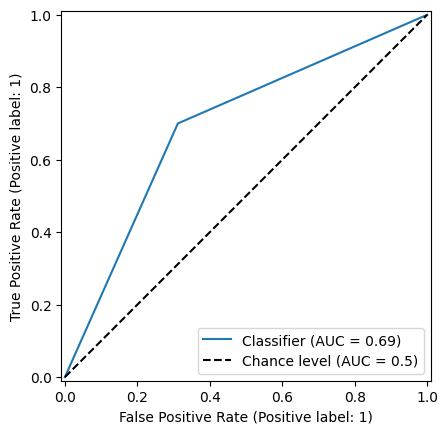

In [23]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, y_predict, plot_chance_level=True)

### Kappa (Cohen's Kappa)

การวัดความเห็นพ้องระหว่างผลการทำนายของโมเดลและค่าจริง

**สูตรการคำนวณ**:

$Kappa = \frac{P_o - P_e}{1 - P_e}$

- $P_o$: สัดส่วนความแม่นยำที่เกิดขึ้นจริง (observed accuracy)
- $P_e$: สัดส่วนความแม่นยำที่เกิดขึ้นแบบสุ่ม (expected accuracy)

```python
from sklearn.metrics import cohen_kappa_score
cohen_kappa_score(y_true, y_pred)
```

In [24]:
from sklearn.metrics import cohen_kappa_score
cohen_kappa_score(y_test, y_predict)

0.38702111024237684

### MCC (Matthews Correlation Coefficient)

การวัดประสิทธิภาพของโมเดลโดยพิจารณาความสัมพันธ์ระหว่างค่าทำนายและค่าจริง

**สูตรการคำนวณ**:

$MCC = \frac{TP \cdot TN - FP \cdot FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$

```python
from sklearn.metrics import matthews_corrcoef
matthews_corrcoef(y_true, y_pred)
```

In [25]:
from sklearn.metrics import matthews_corrcoef
matthews_corrcoef(y_test, y_predict)

0.38750655524123306

## Prediction

* สร้าง DataFrame

  ```
  [5.9, 0.645, 0.12, 2.0, 0.075, 32.0, 35.0, 1, 3.57, 0.71, 11.2]
  ```

In [26]:
wine_new = pd.DataFrame([
    [5.9, 0.645, 0.12, 2.0, 0.075, 32.0, 35.0, 1, 3.57, 0.71, 11.2],
    [2.9, 1.5, 1.12, 3.0, 1.075, 32.0, 30.0, 1, 3.57, 2.71, 9.2]], columns=X_test.columns)
wine_new

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,5.9,0.645,0.12,2.0,0.075,32.0,35.0,1,3.57,0.71,11.2
1,2.9,1.500,1.12,3.0,1.075,32.0,30.0,1,3.57,2.71,9.2


* Predict โดยใช้โมเดลเดิม

In [27]:
wine_cf.predict(wine_new)

array([1, 1])